<a href="https://colab.research.google.com/github/nawanimamta19-byte/Coke-Data-Analysis/blob/main/Rating_and_Reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import pandas as pd

In [4]:
df=pd.read_csv('/content/chatgpt_reviews.csv')
df

,Review Id,Review,Ratings,Review Date
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39
...,...,...,...,...
196722,462686ff-e500-413c-a6b4-2badc2e3b21d,Update 2023,5,2023-07-27 16:26:31
196723,f10e0d48-ecb6-42db-b103-46c0046f9be9,its grear,5,2023-09-23 16:25:18
196724,df909a49-90b5-4dac-9b89-c4bd5a7c2f75,Funtastic App,5,2023-11-08 13:57:14
196725,abe43878-973f-4e96-a765-c4af5c7f7b20,hi all,5,2023-07-25 15:32:57


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196727 entries, 0 to 196726
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Review Id    196727 non-null  object
 1   Review       196721 non-null  object
 2   Ratings      196727 non-null  int64 
 3   Review Date  196727 non-null  object
dtypes: int64(1), object(3)
memory usage: 6.0+ MB


In [6]:
df.describe()

,Ratings
count,196727.000000
mean,4.503535
std,1.083004
min,1.000000
25%,5.000000
50%,5.000000
75%,5.000000
max,5.000000


In [9]:
df.isnull().sum()
# Drop rows where 'Review' is null
df.dropna(subset=['Review'], inplace=True)
print("\nNull values after cleaning:")
df.isnull().sum()


Null values after cleaning:


,0
Review Id,0
Review,0
Ratings,0
Review Date,0


In [10]:
# Convert 'Review Date' to datetime objects
df['Review Date'] = pd.to_datetime(df['Review Date'])

# Extract month from 'Review Date'
df['Month'] = df['Review Date'].dt.to_period('M')

# Calculate the average rating per month
average_rating_per_month = df.groupby('Month')['Ratings'].mean().reset_index()

# Display the result
display(average_rating_per_month)

,Month,Ratings
0,2023-07,4.439454
1,2023-08,4.327746
2,2023-09,4.494534
3,2023-10,4.525755
4,2023-11,4.523913
5,2023-12,4.514217
6,2024-01,4.470955
7,2024-02,4.487997
8,2024-03,4.491531
9,2024-04,4.533934


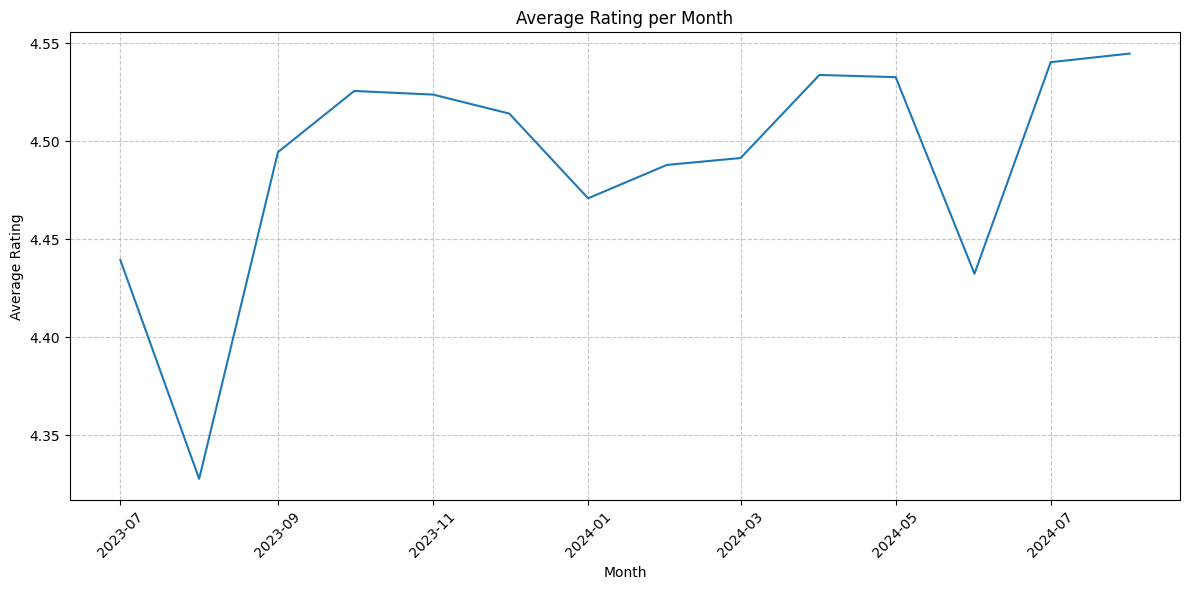

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'Month' column to datetime objects for plotting
average_rating_per_month['Month'] = average_rating_per_month['Month'].dt.to_timestamp()

# Set the figure size for better readability
plt.figure(figsize=(12, 6))

# Create the line plot
sns.lineplot(x='Month', y='Ratings', data=average_rating_per_month)

# Add title and labels
plt.title('Average Rating per Month')
plt.xlabel('Month')
plt.ylabel('Average Rating')

# Rotate x-axis labels if needed for better readability
plt.xticks(rotation=45)

# Add a grid for easier reading of values
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

In [13]:
from textblob import TextBlob

# Function to get sentiment polarity
def get_sentiment(text):
    analysis = TextBlob(text)
    # Return 'Positive' if polarity > 0, 'Negative' if polarity < 0, else 'Neutral'
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment analysis to the 'Review' column
df['Sentiment'] = df['Review'].apply(get_sentiment)

# Display the first few rows with the new 'Sentiment' column
display(df[['Review', 'Ratings', 'Sentiment']].head())

,Review,Ratings,Sentiment
0,good,5,Positive
1,good,5,Positive
2,nice app,5,Positive
3,"nice, ig",5,Positive
4,"this is a great app, the bot is so accurate to...",5,Positive


,count
Sentiment,
Positive,150122
Neutral,38444
Negative,8155


/tmp/ipykernel_1428/1146754109.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


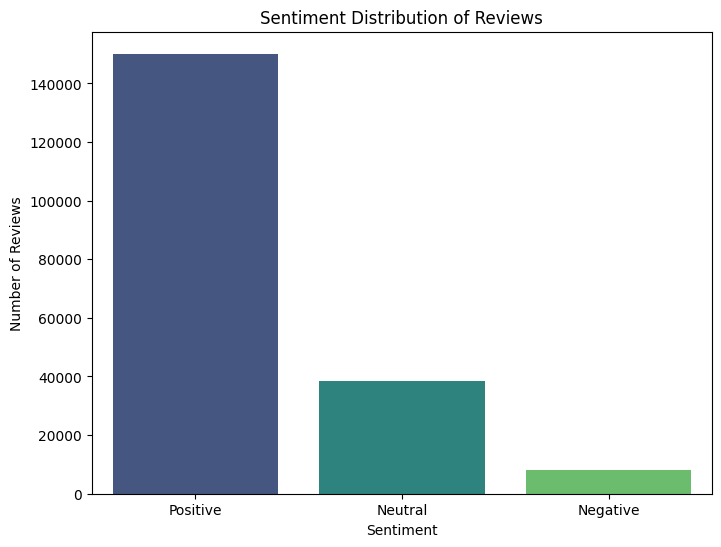

In [14]:
# Display the distribution of sentiments
sentiment_counts = df['Sentiment'].value_counts()
display(sentiment_counts)

# Visualize sentiment distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.title('Sentiment Distribution of Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

In [16]:
sentiment_mapping = {'Positive': 1, 'Neutral': 0, 'Negative': -1}
df['Sentiment_Score'] = df['Sentiment'].map(sentiment_mapping)

average_sentiment_per_month = df.groupby('Month')['Sentiment_Score'].mean().reset_index()

display(average_sentiment_per_month)


,Month,Sentiment_Score
0,2023-07,0.665701
1,2023-08,0.659021
2,2023-09,0.708811
3,2023-10,0.714457
4,2023-11,0.718431
5,2023-12,0.713735
6,2024-01,0.692258
7,2024-02,0.698903
8,2024-03,0.714097
9,2024-04,0.745166


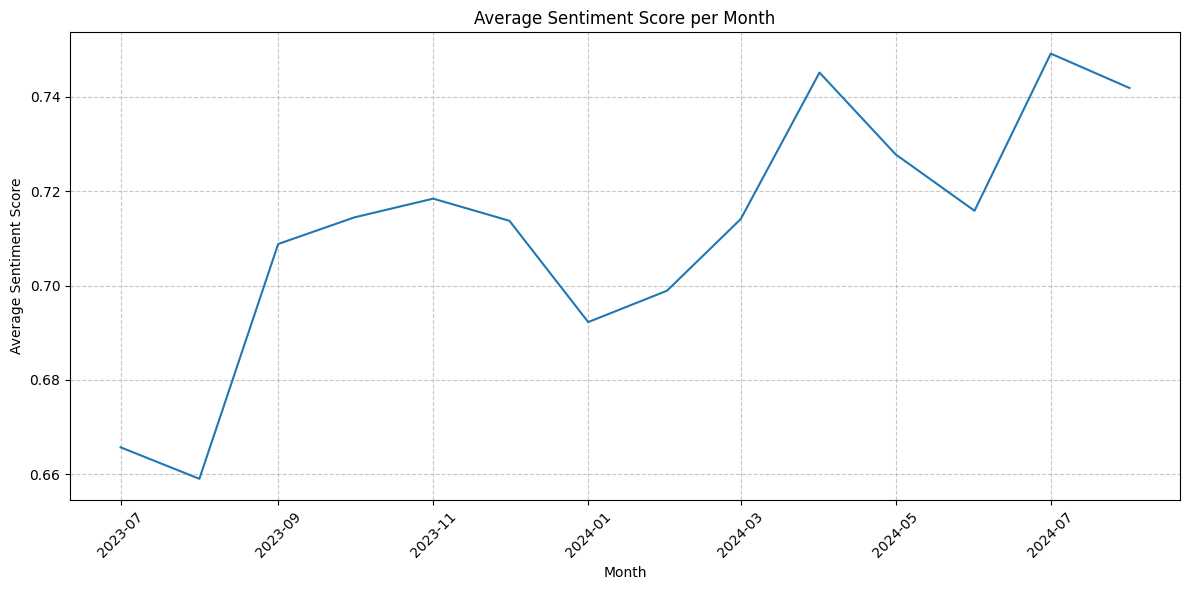

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'Month' column to datetime objects for plotting
average_sentiment_per_month['Month'] = average_sentiment_per_month['Month'].dt.to_timestamp()

# Set the figure size for better readability
plt.figure(figsize=(12, 6))

# Create the line plot
sns.lineplot(x='Month', y='Sentiment_Score', data=average_sentiment_per_month)

# Add title and labels
plt.title('Average Sentiment Score per Month')
plt.xlabel('Month')
plt.ylabel('Average Sentiment Score')

# Rotate x-axis labels if needed for better readability
plt.xticks(rotation=45)

# Add a grid for easier reading of values
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

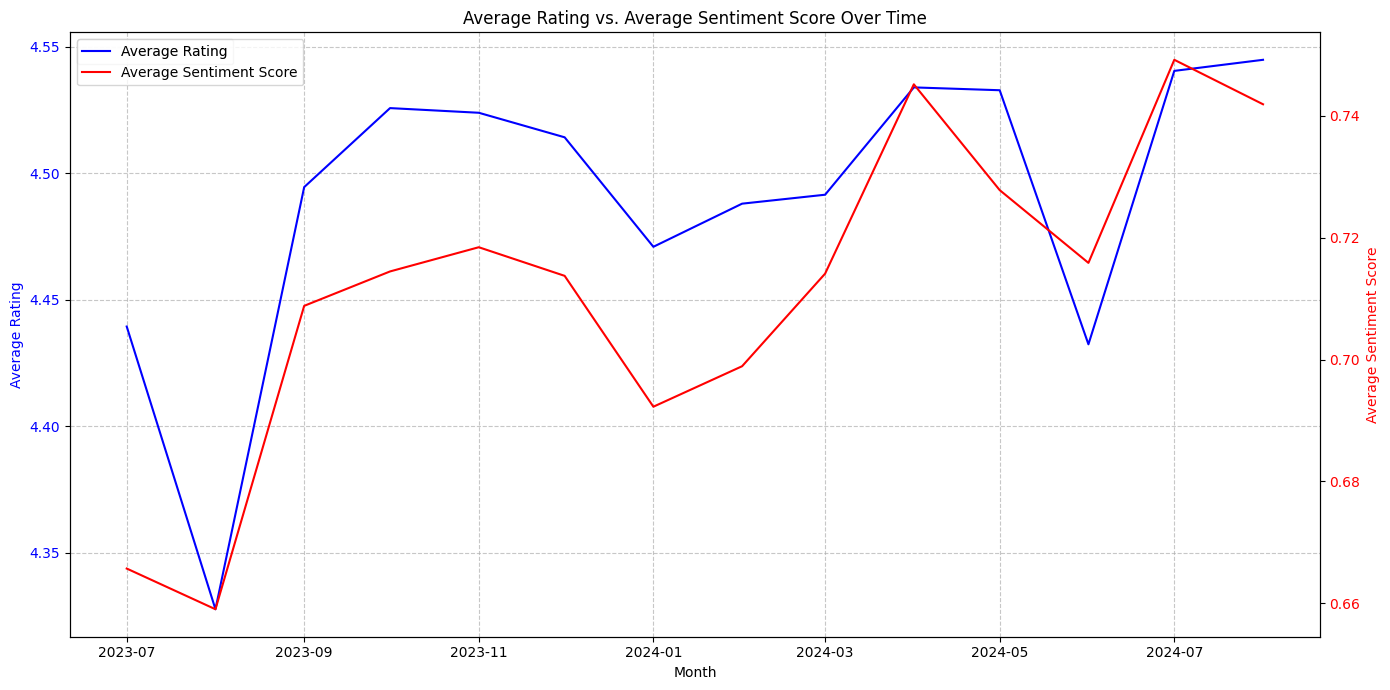

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Month' columns are datetime objects in both dataframes
average_rating_per_month['Month'] = pd.to_datetime(average_rating_per_month['Month'])
average_sentiment_per_month['Month'] = pd.to_datetime(average_sentiment_per_month['Month'])

# Create a figure and a primary axes
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot Average Ratings on the primary y-axis
sns.lineplot(x='Month', y='Ratings', data=average_rating_per_month, ax=ax1, color='blue', label='Average Rating')
ax1.set_xlabel('Month')
ax1.set_ylabel('Average Rating', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a secondary y-axis for Average Sentiment Score
ax2 = ax1.twinx()
sns.lineplot(x='Month', y='Sentiment_Score', data=average_sentiment_per_month, ax=ax2, color='red', label='Average Sentiment Score')
ax2.set_ylabel('Average Sentiment Score', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add title and grid
plt.title('Average Rating vs. Average Sentiment Score Over Time')
ax1.grid(True, linestyle='--', alpha=0.7)

# Add legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [19]:
import nltk
from nltk.corpus import stopwords
from collections import Counter
import re

# Download stopwords if not already downloaded
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

# Filter for positive reviews
positive_reviews_df = df[df['Sentiment'] == 'Positive']

# Combine all positive review text into a single string
all_positive_text = ' '.join(positive_reviews_df['Review'].astype(str))

# Function for text preprocessing
def preprocess_text(text):
    text = text.lower() # Convert to lowercase
    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation and numbers
    words = text.split() # Tokenize
    stop_words = set(stopwords.words('english'))
    words = [word for word in words if word not in stop_words] # Remove stop words
    return words

# Preprocess the combined text
processed_words = preprocess_text(all_positive_text)

# Calculate word frequencies
word_frequencies = Counter(processed_words)

# Get the 20 most common words
most_common_words = word_frequencies.most_common(20)

display(pd.DataFrame(most_common_words, columns=['Word', 'Frequency']))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,Word,Frequency
0,app,44213
1,good,39063
2,best,18317
3,nice,13719
4,great,11876
5,ai,10248
6,helpful,9695
7,amazing,8624
8,love,8557
9,chatgpt,8282


In [22]:
# Calculate the length of each review
positive_reviews_df.loc[:, 'Review_Length'] = positive_reviews_df['Review'].apply(len)

# Sort by review length in descending order and get the top 5
longest_positive_reviews = positive_reviews_df.sort_values(by='Review_Length', ascending=False).head(5)

# Display the reviews
display(longest_positive_reviews[['Review', 'Review_Length']])

,Review,Review_Length
86096,Title: Exceptional Conversational Companion: C...,500
20402,Good luck with you and your family and friends...,500
86005,Subject: Gratitude for an Invaluable ProgramDe...,500
86098,I am also a software developer. I am a web dev...,500
79462,This is toooo helpful for us with doing homewo...,500


In [23]:
# Calculate 'Review_Length' for the entire DataFrame to ensure consistency
df.loc[:, 'Review_Length'] = df['Review'].apply(len)

# Filter for Positive and Negative reviews
positive_and_negative_reviews_df = df[df['Sentiment'].isin(['Positive', 'Negative'])]

# Calculate the average review length for each sentiment category
average_length_by_sentiment = positive_and_negative_reviews_df.groupby('Sentiment')['Review_Length'].mean().reset_index()

display(average_length_by_sentiment)

,Sentiment,Review_Length
0,Negative,106.901655
1,Positive,47.951926


/tmp/ipykernel_1428/149426148.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sentiment', y='Review_Length', data=average_length_by_sentiment, palette='coolwarm')


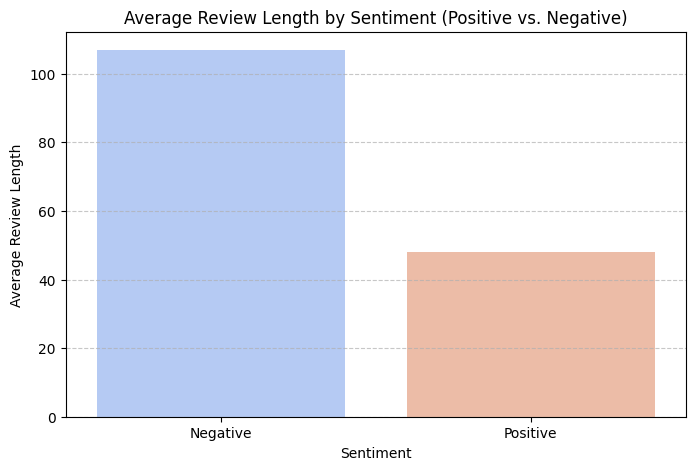

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(x='Sentiment', y='Review_Length', data=average_length_by_sentiment, palette='coolwarm')
plt.title('Average Review Length by Sentiment (Positive vs. Negative)')
plt.xlabel('Sentiment')
plt.ylabel('Average Review Length')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [25]:
# Calculate the count of each rating
rating_counts = df['Ratings'].value_counts().sort_index()

# Display the counts
display(rating_counts)

,count
Ratings,
1,12080
2,3375
3,8157
4,22897
5,150212


/tmp/ipykernel_1428/3647739310.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='viridis')


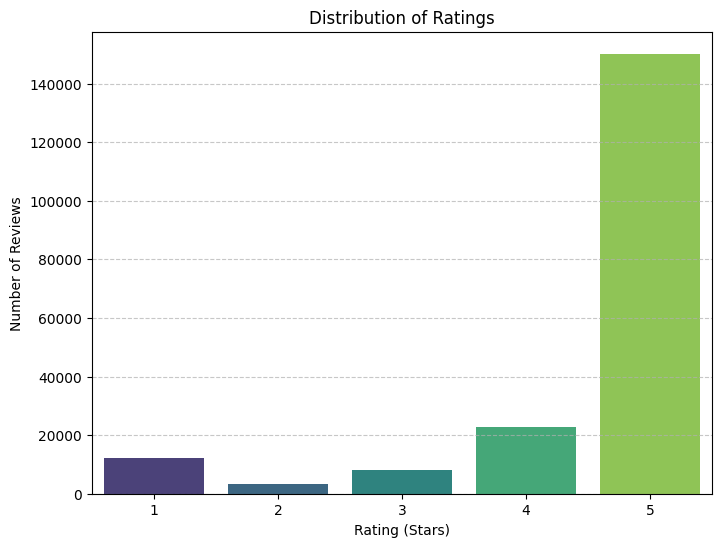

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Rating (Stars)')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [31]:
final_summary = """
### Final Summary of ChatGPT Review Data Analysis

### 1. Data Quality and Cleaning
*   The dataset initially contained some missing values in the 'Review' column, which were successfully dropped, ensuring data integrity for subsequent analyses.

### 2. Overall Review Sentiment & Ratings
*   A significant majority of reviews are **Positive** (around 76%), with about 20% Neutral and a smaller percentage of Negative reviews (4%). This indicates a generally positive user reception for ChatGPT.
*   The average rating is high, consistently around **4.5 out of 5**, which reinforces the positive sentiment.
*   The distribution of ratings shows a very high concentration of 5-star reviews.

### 3. Monthly Trends in Ratings and Sentiment
*   Both the **average rating and average sentiment score showed relatively stable trends over time**, with slight fluctuations, suggesting consistent user experience and satisfaction.
*   The trends for average rating and average sentiment score generally **move in tandem**, indicating a strong correlation between numerical ratings and expressed sentiment.

### 4. Common Themes in Positive Reviews
*   The top words in positive reviews included 'app', 'good', 'best', 'nice', 'great', 'AI', 'helpful', and 'amazing'. This suggests users value the application's overall quality, its AI capabilities, and its helpfulness.

### 5. Common Themes in Negative Reviews
*   The most frequent words in negative reviews included 'app', 'wrong', 'bad', 'chatgpt', 'cant', 'ai', and 'use'. These terms suggest issues related to the app's functionality, performance, or general dissatisfaction with the AI's responses.

### 6. Review Length Analysis
*   **Negative reviews are significantly longer on average** (around 107 characters) compared to positive reviews (around 48 characters). This suggests that users tend to elaborate more when describing negative experiences, seeking to explain specific issues, provide details of their dissatisfaction, or express their emotions in greater detail.
*   The longest positive reviews (up to 500 characters) often provide detailed feedback, personal experiences, or elaborate descriptions, indicating strong user engagement.
"""

with open('final_summary_report.txt', 'w') as f:
    f.write(final_summary)

print("Final summary report saved to 'final_summary_report.txt'")

Final summary report saved to 'final_summary_report.txt'
